In [15]:
import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from PPRCalculator import PPRCalculator
from ModelData import ModelData

# Other tests

In [16]:
# model_number = 496
# model_number = 240
# model_number = 473
# model_number = 240
model_number = 7
model_number = 105
self = PPRCalculator(model_number)
tls = self.get_TL(break_cycles=False, DET_as_PP=True)
tls
# self.get_groups_df()
# self.GS

51    1.000000
50    1.000000
49    1.000000
48    2.000000
47    2.557895
46    2.000000
45    2.000000
44    2.000000
43    2.000000
42    2.456947
41    2.931141
40    3.084426
39    2.918381
38    3.278947
37    3.962739
36    3.383981
35    3.418421
34    4.079139
33    3.286200
32    3.383691
31    3.195263
30    3.257178
29    4.262008
28    4.039071
27    3.589091
26    3.107302
25    3.280185
24    3.355285
23    3.908335
22    4.284176
21    3.849741
20    3.682842
19    4.000049
18    4.215009
17    3.080570
16    3.021204
15    3.121576
14    4.224592
13    4.382093
12    3.365384
11    3.446879
10    3.621015
9     3.953452
8     3.533849
7     4.280328
6     3.000000
5     4.422608
4     4.125564
3     4.402161
2     4.100458
1     3.313252
dtype: float64

# GS distribution

In [17]:
path = 'real_models/data/'
saved_models = [int(f.split('[')[1].split(']')[0]) for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

In [18]:
gs_list = []
tl_list = []
tl_groups_list = []
trophic_info_list = []
models_list = []
names_list = []

for model_number in tqdm(saved_models):
    # create model calculator:
    try:
        model = PPRCalculator(model_number)
        groups_df = model.get_groups_df()
        groups_df['tl'] = model.get_TL(break_cycles=False, DET_as_PP=True)
        groups_df['gs'] = model.GS.fillna(0)
        groups_df['tl_groups'] = groups_df['tl'].copy()
        groups_df = groups_df[['group_name', 'trophic_info', 'tl', 'tl_groups', 'gs']]
        groups_df.loc[~groups_df['tl_groups'].isin([1, 2]), 'tl_groups'] = 0
        tl_list += groups_df['tl'].tolist()
        tl_groups_list += groups_df['tl_groups'].tolist()
        gs_list += groups_df['gs'].tolist()
        trophic_info_list += groups_df['trophic_info'].tolist()
        names_list += groups_df['group_name'].tolist()
        models_list += [model_number] * len(groups_df)
    except:
        print(model_number)
        continue

  0%|          | 0/119 [00:00<?, ?it/s]

In [19]:
df = pd.DataFrame(data={
    'model_number': models_list,
    'trophic_info': trophic_info_list,
    'group_name': names_list,
    'tl': tl_list,
    'tl_groups': tl_groups_list,
    'gs': gs_list,
})
df

,model_number,trophic_info,group_name,tl,tl_groups,gs
0,105,Import,diet_import,1.000000,1.0,0.0
1,105,DET,Detritus,1.000000,1.0,0.0
2,105,PP,Phytoplankton,1.000000,1.0,0.0
3,105,Regular,S.Zooplankton,2.000000,2.0,0.2
4,105,Regular,L.Zooplankton,2.557895,0.0,0.2
...,...,...,...,...,...,...
3461,7,Regular,Loligo,3.958886,0.0,0.2
3462,7,Regular,large zoopl,2.765306,0.0,0.4
3463,7,Regular,small zoopl,2.000000,2.0,0.4
3464,7,PP,macrophytes,1.000000,1.0,0.0


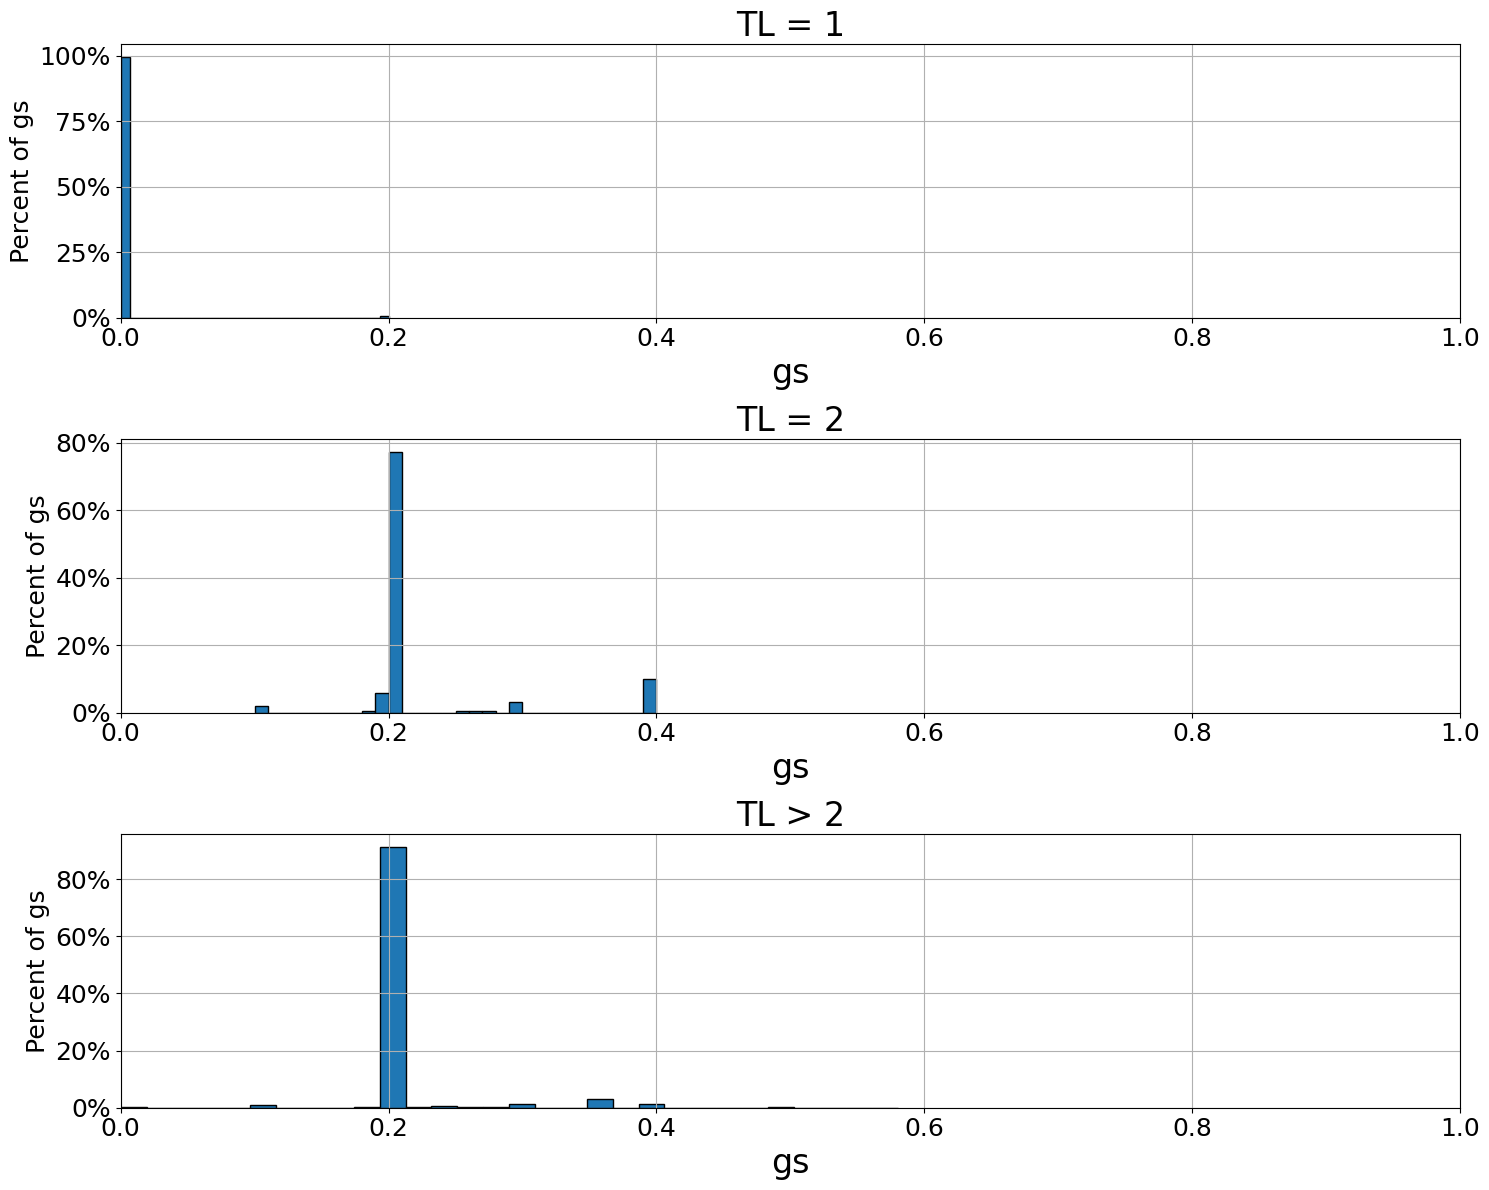

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

for i, tl_value in enumerate([1, 2, 0]):
    subset = df[df["tl_groups"] == tl_value]["gs"].dropna()
    weights = np.ones_like(subset) / len(subset)
    axes[i].hist(subset, bins=30, weights=weights, edgecolor="black")
    if tl_value == 0:
        axes[i].set_title(f"TL > 2", fontsize=24)
    else:
        axes[i].set_title(f"TL = {tl_value}", fontsize=24)
    axes[i].set_xlabel("gs", fontsize=24)
    axes[i].tick_params(axis="both", labelsize=18)
    axes[i].set_ylabel("Percent of gs", fontsize=18)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].set_xlim(0, 1)
    axes[i].grid(True)

fig.tight_layout()
plt.show()

In [26]:
model_numbers_non_default = [108,
 116,
 125,
 145,
 153,
 168,
 172,
 217,
 218,
 227,
 232,
 269,
 282,
 311,
 312,
 410,
 413,
 459,
 462,
 464,
 473,
 485,
 487,
 488,
 497,
 499,
 500,
 501,
 502,
 503,
 504,
 505,
 506,
 520,
 633,
 634,
 646,
 650,
 651,
 654,
 658,
 680,
 687,
 689,
 725,
 726,
 7]

In [3]:
model = PPRCalculator(459, underdetermined=False, zero_catch=True, zero_biomass_accum=False, default_gs=True, weight_flow=1.0, weight_guess=0.0)
model.get_groups_df().round(5)[['group_name', 'trophic_info', 'tl', 'ee', 'p', 'q', 'biomass_accum', 'net_migration', 'M0', 'predation', 'catch', 'gs', 'egestion', 'respiration']]
# model.get_PPR(model.SPPR_new(TE_option='TE')[0], only_inner=True).sum(axis=1)

,group_name,trophic_info,tl,ee,p,q,biomass_accum,net_migration,M0,predation,catch,gs,egestion,respiration
group_seq,,,,,,,,,,,,,,
32,diet_import,Import,1.00000,1.00000,84.56694,84.56694,0.00000,0.0,0.00000,84.56694,0.00000,0.0,0.00000,0.00000
31,Detritus,DET,1.00000,1.00000,1642.61581,1642.61581,491.83744,0.0,0.00000,1150.77837,0.00000,0.0,0.00000,0.00000
30,Phytoplankton,PP,1.00000,0.84209,1369.60000,1369.60000,0.00000,0.0,216.27271,1153.32722,0.00000,0.0,0.00000,0.00000
29,Large zooplankton,Regular,3.00597,0.15243,83.83320,279.44400,0.00000,0.0,71.05464,12.77856,0.00000,0.4,111.77760,83.83320
28,Small zooplankton,Regular,2.00301,0.66559,692.00000,2308.00000,0.00000,0.0,231.41099,460.58896,0.00000,0.4,923.20000,692.80000
27,Large squids,Regular,4.39837,0.35927,0.81460,2.80862,0.00000,0.0,0.52194,0.29266,0.00001,0.2,0.56172,1.43229
26,Small squids,Regular,3.86046,0.95000,6.36594,21.21593,0.00000,0.0,0.31830,6.04764,0.00000,0.2,4.24319,10.60681
25,Other turtles,Regular,3.50449,0.99000,0.00012,0.00268,0.00000,0.0,0.00000,0.00008,0.00003,0.2,0.00054,0.00203
24,Leatherback turtle,Regular,3.98591,0.99000,0.00009,0.00199,0.00000,0.0,0.00000,0.00008,0.00001,0.2,0.00040,0.00151


In [22]:
modeldata = ModelData(459)

modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan
# modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan

model = PPRCalculator.from_modeldata(modeldata, underdetermined=True, zero_catch=True, zero_biomass_accum=True, default_gs=False, weight_flow=1.0, weight_guess=0.0)
model.get_groups_df().round(5)[['group_name', 'trophic_info', 'tl', 'ee', 'p', 'q', 'biomass_accum', 'net_migration', 'M0', 'predation', 'catch', 'gs', 'egestion', 'respiration']]

# model.get_PPR(model.SPPR_new(TE_option='TE')[0], only_inner=True).sum(axis=1)

,group_name,trophic_info,tl,ee,p,q,biomass_accum,net_migration,M0,predation,catch,gs,egestion,respiration
group_seq,,,,,,,,,,,,,,
32,diet_import,Import,1.00000,1.00000,84.56694,84.56694,0.00000,0.0,0.00000,84.56694,0.00000,0.00000,0.00000,0.00000
31,Detritus,DET,1.00000,1.00000,962.31402,962.31402,-188.46435,0.0,0.00000,1150.77837,0.00000,0.00000,0.00000,0.00000
30,Phytoplankton,PP,1.00000,0.84209,1369.60000,1369.60000,0.00000,0.0,216.27271,1153.32722,0.00000,0.00000,0.00000,0.00000
29,Large zooplankton,Regular,3.00597,0.15243,83.83320,279.44400,0.00000,0.0,71.05464,12.77856,0.00000,0.10000,27.94440,167.66640
28,Small zooplankton,Regular,2.00301,0.66559,692.00000,2308.00000,0.00000,0.0,231.41099,460.58896,0.00000,0.15559,359.11111,1256.88889
27,Large squids,Regular,4.39837,0.35927,0.81460,2.80862,0.00000,0.0,0.52194,0.29266,0.00001,0.10000,0.28086,1.71315
26,Small squids,Regular,3.86046,0.95000,6.36594,21.21593,0.00000,0.0,0.31830,6.04764,0.00000,0.10000,2.12159,12.72840
25,Other turtles,Regular,3.50449,0.99000,0.00012,0.00268,0.00000,0.0,0.00000,0.00008,0.00003,0.21270,0.00057,0.00200
24,Leatherback turtle,Regular,3.98591,0.99000,0.00009,0.00199,0.00000,0.0,0.00000,0.00008,0.00001,0.21270,0.00042,0.00148


In [51]:
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# model_numbers_non_default = df.loc[~df["gs"].isin([0, 0.2]), "model_number"].unique().tolist()

results = {
    'model_number': [],
    'is_gs_default': [],
    'SPPR_1986': [],
    'SPPR_1995': [],
    'SPPR_new_TE': [],
    'SPPR_new_GE': [],
    # 'SPPR_EwE': [],
    # 'SPPR_2015': [],
}

for model_number in tqdm(saved_models):
    # index:
    results['model_number'].append(model_number)
    results['is_gs_default'].append(model_number not in model_numbers_non_default)

    # full data:
    model = PPRCalculator(model_number)
    results['SPPR_1986'].append(model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())
    results['SPPR_1995'].append(model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())
    results['SPPR_new_TE'].append(model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())
    results['SPPR_new_GE'].append(model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())
    # results['SPPR_EwE'].append(model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum())
    # results['SPPR_2015'].append(model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())

    # partial data:
    modeldata = ModelData(model_number)

    modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan
    # modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum']] = np.nan
    # modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan

    model = PPRCalculator.from_modeldata(modeldata, underdetermined=True, zero_catch=True, zero_biomass_accum=False, default_gs=False, weight_flow=1.0, weight_guess=1.0)
    results['SPPR_1986'][-1] = abs((results['SPPR_1986'][-1] - model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())) / results['SPPR_1986'][-1]
    results['SPPR_1995'][-1] = abs((results['SPPR_1995'][-1] - model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())) / results['SPPR_1995'][-1]
    results['SPPR_new_TE'][-1] = abs((results['SPPR_new_TE'][-1] - model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_TE'][-1]
    results['SPPR_new_GE'][-1] = abs((results['SPPR_new_GE'][-1] - model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_GE'][-1]
    # results['SPPR_EwE'][-1] = (results['SPPR_EwE'][-1] - model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum()) / results['SPPR_EwE'][-1]
    # results['SPPR_2015'][-1] = abs((results['SPPR_2015'][-1] - model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_2015'][-1]

df_results = pd.DataFrame(results)

  0%|          | 0/119 [00:00<?, ?it/s]

In [52]:
df_results

,model_number,is_gs_default,SPPR_1986,SPPR_1995,SPPR_new_TE,SPPR_new_GE
0,105,True,0.0,0.0,0.020134,0.046807
1,107,True,0.0,0.0,0.042834,0.217276
2,108,False,0.0,0.0,0.135865,9.417520
3,111,True,0.0,0.0,0.012612,1.260206
4,112,True,0.0,0.0,0.012514,1.456913
...,...,...,...,...,...,...
114,692,True,0.0,0.0,0.021955,0.047380
115,693,True,0.0,0.0,0.013993,0.021679
116,725,False,0.0,0.0,0.046194,0.587945
117,726,False,0.0,0.0,0.034349,1.877149


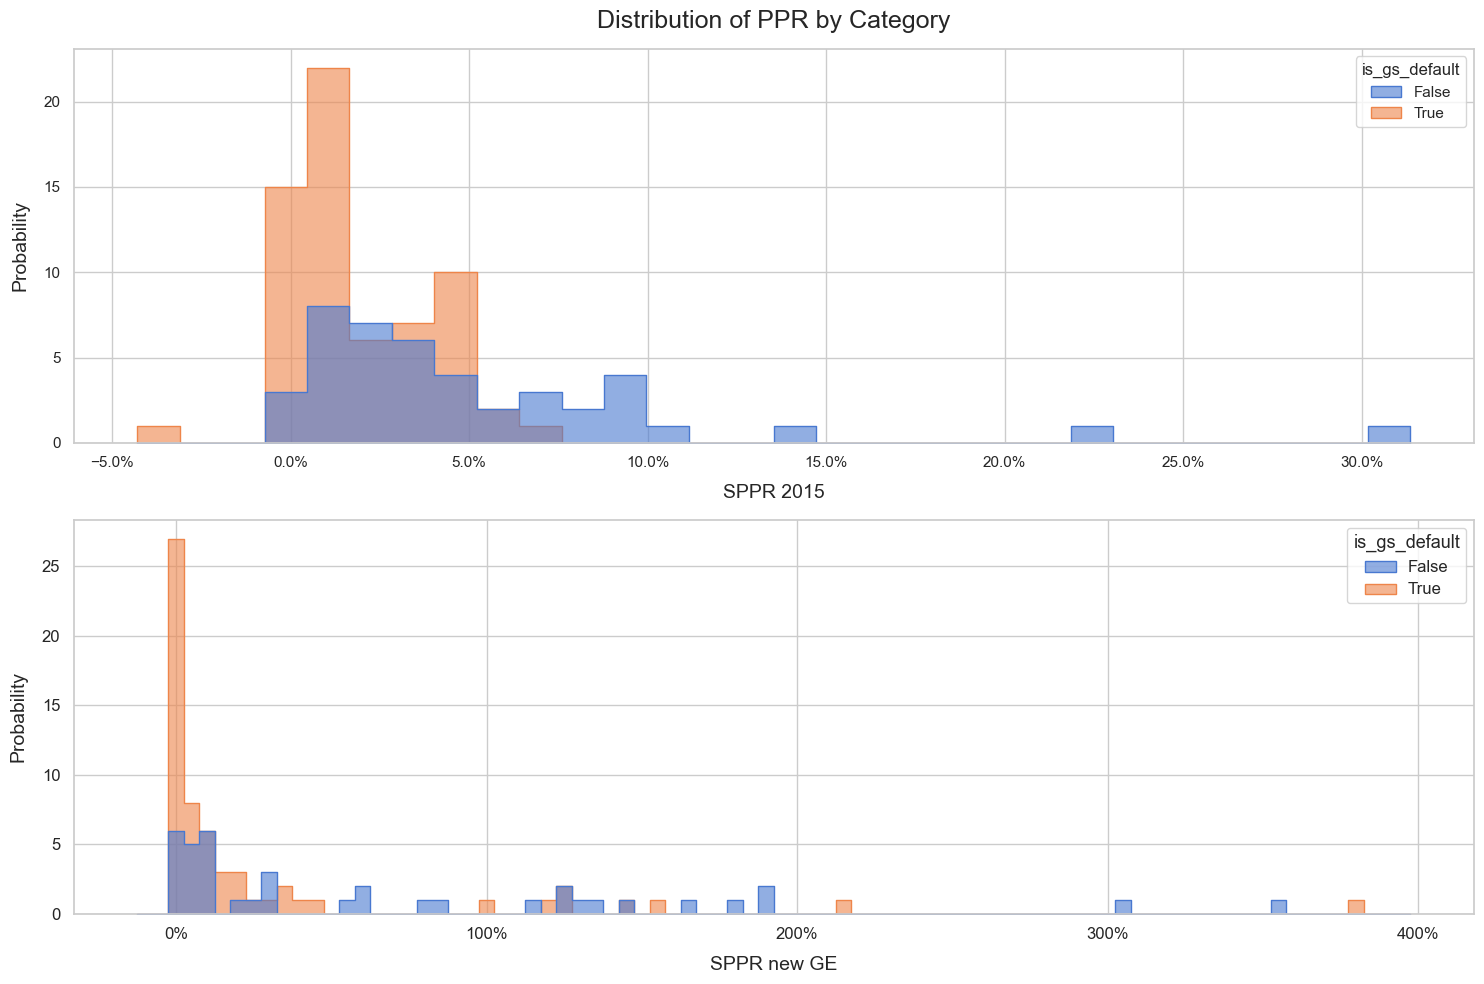

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


df_viz = df_results.copy()
df_viz['SPPR_new_TE'] *= 100
df_viz['SPPR_new_GE'] *= 100

# Set a clean background style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_TE",
    bins=30,
    # bins=np.arange(-12.5, 112.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[0]
)

# Customize titles and labels with big fonts
ax.set_title("Distribution of PPR by Category", fontsize=18, pad=15)
ax.set_xlabel("SPPR 2015", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_GE",
    # bins=30,
    bins=np.arange(-12.5, 402.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[1]
)

# Customize titles and labels with big fonts
ax.set_xlabel("SPPR new GE", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Make axis tick marks larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make the legend text larger
plt.setp(ax.get_legend().get_texts(), fontsize="12")
plt.setp(ax.get_legend().get_title(), fontsize="13")

# Adjust spacing and display
plt.tight_layout()
plt.show()